In [2]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle, Ring

# L3 Cavity with Oxidized Holes — Extended optimization (3-row, 10-hole)
Optimized L3 cavity (GaAs, extended 15-parameter optimization across 3 rows of neighbors)
with thin oxide rings on hole sidewalls. Sweeps oxide thickness to study effect on Q.

Optimization result: Q = 42,103,899 (6637x improvement over single-hole)

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


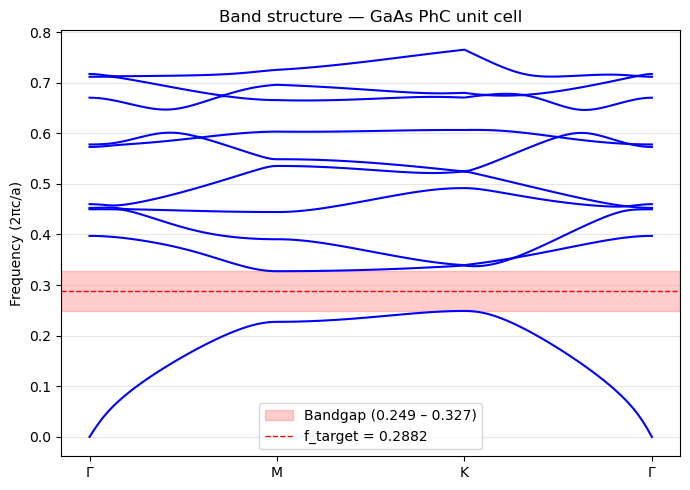

In [3]:
# ── Band structure of the perfect PhC (unit cell) ────────────────────────────────────────

# ── Physical parameters ───────────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ── Supercell parameters ─────────────────────────────────────────────────────────
Nx, Ny = 16, 10

# Oxide material
n_oxide = 1.72
eps_oxide = n_oxide**2

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Extended optimization shifts (15 params, 10 holes, 3 rows)
# From autograd optimization: Q = 43,709,608
dx = np.zeros(nc)
dy = np.zeros(nc)

# Row 0 (yp=0): ic=0..3 → xp=2,3,4,5 — dx only
dx[0] = 0.27487    # xp=2.0, 68.7 nm
dx[1] = 0.23278    # xp=3.0, 58.2 nm
dx[2] = -0.00241   # xp=4.0, -0.6 nm
dx[3] = 0.12142    # xp=5.0, 30.4 nm

# Row 1 (yp=0.866): ic=7,8,9 → xp=0.5,1.5,2.5 — dx and dy
dx[7] = 0.00094;  dy[7] = 0.02053   # 0.2 nm, 5.1 nm
dx[8] = 0.00873;  dy[8] = 0.00237   # 2.2 nm, 0.6 nm
dx[9] = 0.00226;  dy[9] = 0.00513   # 0.6 nm, 1.3 nm

# Row 2 (yp=1.732): ic=16,17,18 → xp=0,1,2 — dy (and dx for ic=17,18)
dy[16] = 0.01433                      # 3.6 nm (xp=0, no dx by symmetry)
dx[17] = -0.00962;  dy[17] = 0.00565  # -2.4 nm, 1.4 nm
dx[18] = -0.01077;  dy[18] = 0.01215  # -2.7 nm, 3.0 nm

# Summary of shifted holes
shifted_ics = [0, 1, 2, 3, 7, 8, 9, 16, 17, 18]
print(f'nc = {nc} holes per quadrant')
print(f'Extended optimization shifts ({len(shifted_ics)} holes):')
print(f'{"Row":>5} {"ic":>4} {"xp":>6} {"yp":>6} {"dx(a)":>8} {"dy(a)":>8} {"dx(nm)":>8} {"dy(nm)":>8}')
print('-' * 60)
for ic in shifted_ics:
    row = 0 if yp[ic] == 0 else (1 if yp[ic] < 1.0 else 2)
    print(f'{row:>5} {ic:>4} {xp[ic]:>6.1f} {yp[ic]:>6.3f} {dx[ic]:>8.5f} {dy[ic]:>8.5f} {dx[ic]*a_nm:>8.1f} {dy[ic]*a_nm:>8.1f}')

nc = 52 holes per quadrant
Extended optimization shifts (10 holes):
  Row   ic     xp     yp    dx(a)    dy(a)   dx(nm)   dy(nm)
------------------------------------------------------------
    0    0    2.0  0.000  0.27487  0.00000     68.7      0.0
    0    1    3.0  0.000  0.23278  0.00000     58.2      0.0
    0    2    4.0  0.000 -0.00241  0.00000     -0.6      0.0
    0    3    5.0  0.000  0.12142  0.00000     30.4      0.0
    1    7    0.5  0.866  0.00094  0.02053      0.2      5.1
    1    8    1.5  0.866  0.00873  0.00237      2.2      0.6
    1    9    2.5  0.866  0.00226  0.00513      0.6      1.3
    2   16    0.0  1.732  0.00000  0.01433      0.0      3.6
    2   17    1.0  1.732 -0.00962  0.00565     -2.4      1.4
    2   18    2.0  1.732 -0.01077  0.01215     -2.7      3.0


In [5]:
import os
from datetime import datetime

SAVE_DATA = True

def save_sweep(name, arrays_dict, **extra_params):
    """Save sweep results to a timestamped folder in data/.

    Parameters
    ----------
    name : str
        Short sweep name (used in folder name).
    arrays_dict : dict
        {label: np.array} \u2014 each array is saved as a .npy file.
    **extra_params :
        Sweep-specific parameters to log in info.txt.
    """
    if not SAVE_DATA:
        return
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{name}')
    os.makedirs(folder, exist_ok=True)

    # Save arrays
    for label, arr in arrays_dict.items():
        np.save(os.path.join(folder, f'{label}.npy'), np.asarray(arr))

    # Write info.txt
    with open(os.path.join(folder, 'info.txt'), 'w') as f:
        f.write(f'Sweep: {name}\n')
        f.write(f'Date: {timestamp}\n\n')

        f.write('--- Physical parameters ---\n')
        f.write(f'a_nm = {a_nm}\n')
        f.write(f'ra = {ra:.4f} ({ra * a_nm:.1f} nm)\n')
        f.write(f'dslab = {dslab:.4f} ({dslab * a_nm:.1f} nm)\n')
        f.write(f'n_slab = {n_slab}\n')
        f.write(f'n_oxide = {n_oxide}\n')
        f.write(f'eps_oxide = {eps_oxide:.4f}\n\n')

        f.write('--- Supercell ---\n')
        f.write(f'Nx = {Nx}, Ny = {Ny}\n')
        f.write(f'nc = {nc}\n')
        f.write(f'Optimization: extended (3-row, 10-hole, 15 params)\n')
        for ic in shifted_ics:
            f.write(f'  ic={ic}: xp={xp[ic]:.1f}, yp={yp[ic]:.3f}, '
                    f'dx={dx[ic]:.5f}a ({dx[ic]*a_nm:.1f} nm), '
                    f'dy={dy[ic]:.5f}a ({dy[ic]*a_nm:.1f} nm)\n')
        f.write('\n')

        f.write('--- GME settings ---\n')
        f.write(f'gmax = {gmax}\n')
        f.write(f'truncate_g = {truncate_g}\n')
        f.write(f'numeig = 10\n')
        f.write(f'gmode_inds = [0]\n\n')

        f.write('--- Bandgap ---\n')
        f.write(f'f_lb = {f_lb:.6f}\n')
        f.write(f'f_ub = {f_ub:.6f}\n')
        f.write(f'f_target = {f_target:.6f}\n')
        f.write(f'f_base = {f_base:.6f}\n')
        f.write(f'Q_base = {Q_base:.1f}\n\n')

        f.write('--- Sweep-specific parameters ---\n')
        for k, v in extra_params.items():
            f.write(f'{k} = {v}\n')

        f.write(f'\n--- Saved arrays ---\n')
        for label in arrays_dict:
            f.write(f'{label}.npy\n')

    print(f'Results saved to {folder}/')

In [6]:
def cavity_oxidized_ext(t_ox_nm, consume_ratio=0.5, r_nm=None):
    """Build an L3 cavity with oxide on ALL exposed surfaces (extended optimization).

    Uses the 15-parameter extended optimization result (10 holes, 3 rows,
    dx+dy shifts). Oxide grows both into the GaAs (consuming it) and outward.

    Parameters
    ----------
    t_ox_nm : float
        Total oxide thickness in nm. Set to 0 for unoxidized cavity.
    consume_ratio : float, optional
        Fraction of oxide that replaces GaAs (0 to 1). Default 0.5.
    r_nm : float or None, optional
        Hole radius in nm. If None, uses the global `ra` (75 nm default).
    """
    t_ox = t_ox_nm / a_nm  # nm \u2192 normalized units
    r_a = (r_nm / a_nm) if r_nm is not None else ra

    dx_local = dx.copy()
    dy_local = dy.copy()

    if t_ox_nm > 0:
        d_consume = consume_ratio * t_ox
        d_slab_eff = dslab - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox_nm} nm '
                f'>= dslab = {dslab * a_nm} nm')
        r_outer = r_a + consume_ratio * t_ox
        r_inner = r_a - (1 - consume_ratio) * t_ox
    else:
        d_slab_eff = dslab

    phc = legume.PhotCryst(lattice)

    if t_ox_nm > 0:
        # Layer 0: bottom oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
        # Layer 1: thinned GaAs slab
        phc.add_layer(d=d_slab_eff, eps_b=n_slab**2)
        # Layer 2: top oxide film
        phc.add_layer(d=t_ox, eps_b=eps_oxide)
    else:
        # No oxide: single slab layer (layer 0)
        phc.add_layer(d=dslab, eps_b=n_slab**2)

    slab_idx = 1 if t_ox_nm > 0 else 0

    for ic in range(nc):
        yc = yp[ic] + dy_local[ic]
        xc = xp[ic] + dx_local[ic] if xp[ic] != 0 else 0.0

        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            if t_ox_nm > 0:
                # Slab layer: oxide ring (consumes GaAs + grows into air)
                phc.add_shape(Ring(eps=eps_oxide, r_i=r_inner, r_o=r_outer,
                                  x_cent=px, y_cent=py), layer=slab_idx)
                phc.add_shape(Circle(eps=1.0, r=r_inner,
                                    x_cent=px, y_cent=py), layer=slab_idx)
                # Oxide layers: air holes punch through
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=0)
                phc.add_shape(Circle(eps=1.0, r=r_outer,
                                    x_cent=px, y_cent=py), layer=2)
            else:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_a))

    return phc

## Visualize structure

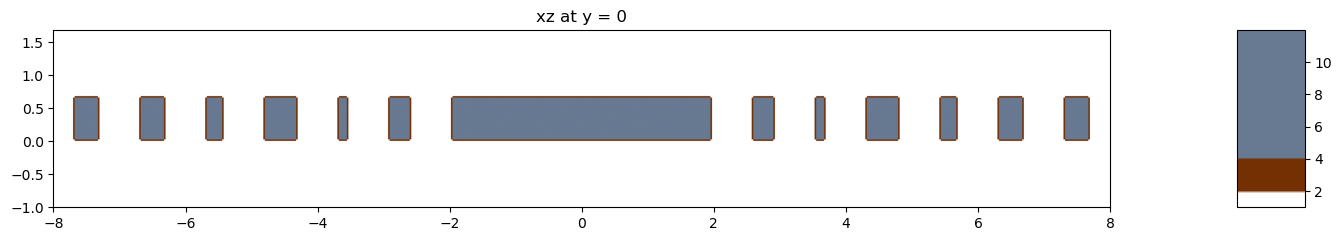

In [7]:
# Visualize the oxidized cavity (t_ox = 5 nm)
phc_viz = cavity_oxidized_ext(6, consume_ratio=1.0)
gme_viz = legume.GuidedModeExp(phc_viz, gmax=2, truncate_g='tbt')

# Discrete colormap: air=white, oxide=brown, GaAs=blue-grey
import matplotlib.colors as mcolors
cmap_discrete = mcolors.LinearSegmentedColormap.from_list('discrete_eps', [
    (0.00, 'white'),     # air
    (0.08, 'white'),
    (0.09, '#743003'),   # oxide
    (0.27, '#743003'),
    (0.28, '#687992'),   # GaAs
    (1.00, '#687992')
])

legume.viz.structure(phc_viz, xz=True, yz=False, xy=False, figsize=14, cmap=cmap_discrete,
                     Nx=2000, Ny=1000, Nz=600)

## Baseline: unoxidized L3 cavity (extended optimization)

23.999s total time for real part of frequencies in GuidedModeExp, of which
  0.156s (1%) for guided modes computation using the gmode_compute='exact' method
  0.711s (3%) for inverse matrix of Fourier-space permittivity
  20.115s (84%) for matrix diagionalization using the 'eigh' solver
  3.015s (13%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.25552,  Q = 43715162.6 <-- IN BANDGAP
  Mode 1: f = 0.26460,  Q = 3629.8 <-- IN BANDGAP
  Mode 2: f = 0.27677,  Q = 905.2 <-- IN BANDGAP
  Mode 3: f = 0.27761,  Q = 254.9 <-- IN BANDGAP
  Mode 4: f = 0.28124,  Q = 284.9 <-- IN BANDGAP
  Mode 5: f = 0.28397,  Q = 1945.0 <-- IN BANDGAP
  Mode 6: f = 0.30828,  Q = 2513.9 <-- IN BANDGAP
  Mode 7: f = 0.30877,  Q = 1742.8 <-- IN BANDGAP
  Mode 8: f = 0.30888,  Q = 1783.9 <-- IN BANDGAP
  Mode 9: f = 0.31944,  Q = 3303.8 

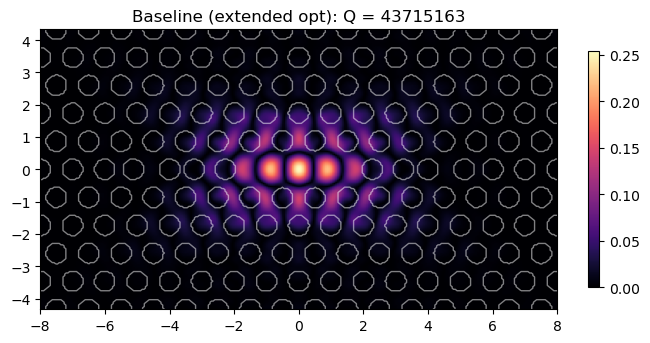

In [8]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx', 'compute_im': False}

# Unoxidized cavity
phc_base = cavity_oxidized_ext(0)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify the L3 cavity mode (first mode in bandgap)
print(f'\nModes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (no oxide, extended opt): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline (extended opt): Q = {Q_base:.0f}')
plt.show()

## Single oxidized run

17.015s total time for real part of frequencies in GuidedModeExp, of which
  0.230s (1%) for guided modes computation using the gmode_compute='exact' method
  1.262s (7%) for inverse matrix of Fourier-space permittivity
  12.459s (73%) for matrix diagionalization using the 'eigh' solver
  3.061s (18%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
t_ox = 4.5 nm:  f = 0.25979,  Q = 671.2
Change from baseline:  Δf = 0.00427,  ΔQ = -43714491.5


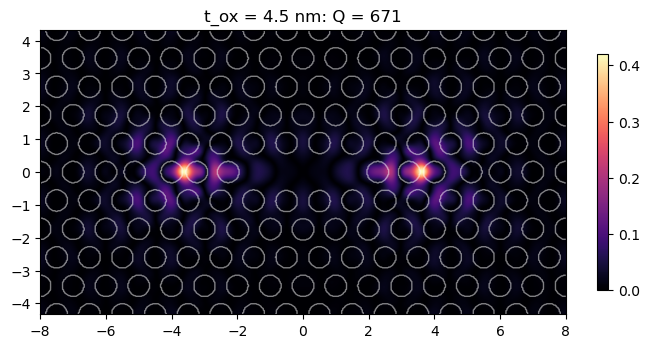

In [24]:
# Single oxidized run (t_ox = 4.5 nm)
t_ox_test = 4.5  # nm

phc_ox = cavity_oxidized_ext(t_ox_test, consume_ratio=1.0)
gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
gme_ox.run(kpoints=np.array([[0], [0]]), **options)

# Find cavity mode: candidates near f_base, pick highest Q
all_freqs_ox = gme_ox.freqs[0, :]
candidates = np.where(np.abs(all_freqs_ox - f_base) < 0.005)[0]
best_Q_ox, mind_ox = -1, 0
for c in candidates:
    (fim, _, _) = gme_ox.compute_rad(0, [c])
    Qc = gme_ox.freqs[0, c] / (2 * fim[0])
    if Qc > best_Q_ox:
        best_Q_ox, mind_ox = Qc, c

Q_ox = best_Q_ox
f_ox = gme_ox.freqs[0, mind_ox]

print(f't_ox = {t_ox_test} nm:  f = {f_ox:.5f},  Q = {Q_ox:.1f}')
print(f'Change from baseline:  \u0394f = {f_ox - f_base:.5f},  \u0394Q = {Q_ox - Q_base:.1f}')

ax = legume.viz.field(gme_ox, 'e', 0, mind_ox, z=dslab/2,
                      component='y', val='abs', N1=500, N2=400)
plt.title(f't_ox = {t_ox_test} nm: Q = {Q_ox:.0f}')
plt.show()

## Q factor vs oxide thickness

In [25]:
# Sweep oxide thickness (consume_ratio = 0.5)
t_ox_values = np.linspace(0, 10, 21)  # nm
Qs_full = []
freqs_full = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking with baseline L3 frequency

print('Sweeping oxide thickness (consume_ratio = 0.5):')
for t_ox_nm in t_ox_values:
    phc_s = cavity_oxidized_ext(t_ox_nm)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Q-based mode selection: find candidates near f_prev, pick highest Q
    all_freqs = gme_s.freqs[0, :]
    candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_s.compute_rad(0, [c])
        Qc = gme_s.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s

    Qs_full.append(best_Q)
    freqs_full.append(f_s)
    print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

if SAVE_DATA:
    save_sweep('ext_oxide_thickness', {
        't_ox_nm': t_ox_values,
        'Qs': np.array(Qs_full),
        'freqs': np.array(freqs_full),
    }, consume_ratio=0.5, r_nm=75)

Sweeping oxide thickness (consume_ratio = 0.5):
  t_ox =  0.00 nm,  Q = 43715162.6,  f = 0.25552  (mode 8)
  t_ox =  0.50 nm,  Q = 36548681.1,  f = 0.25574  (mode 8)
  t_ox =  1.00 nm,  Q = 24737324.9,  f = 0.25597  (mode 8)
  t_ox =  1.50 nm,  Q = 15771467.9,  f = 0.25620  (mode 8)
  t_ox =  2.00 nm,  Q = 10211851.1,  f = 0.25643  (mode 8)
  t_ox =  2.50 nm,  Q =  6850768.7,  f = 0.25666  (mode 8)
  t_ox =  3.00 nm,  Q =  4762138.2,  f = 0.25689  (mode 8)
  t_ox =  3.50 nm,  Q =  3412373.6,  f = 0.25713  (mode 8)
  t_ox =  4.00 nm,  Q =  2506139.5,  f = 0.25737  (mode 8)
  t_ox =  4.50 nm,  Q =  1876767.0,  f = 0.25761  (mode 8)
  t_ox =  5.00 nm,  Q =  1426828.0,  f = 0.25786  (mode 8)
  t_ox =  5.50 nm,  Q =  1097190.6,  f = 0.25810  (mode 8)
  t_ox =  6.00 nm,  Q =   850669.1,  f = 0.25835  (mode 8)
  t_ox =  6.50 nm,  Q =   663114.0,  f = 0.25860  (mode 8)
  t_ox =  7.00 nm,  Q =   518385.5,  f = 0.25886  (mode 8)
  t_ox =  7.50 nm,  Q =   405417.4,  f = 0.25911  (mode 8)
  t_ox =

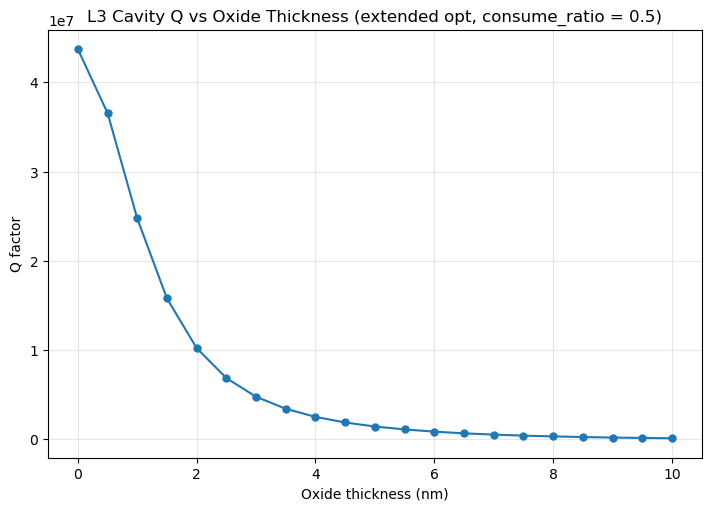

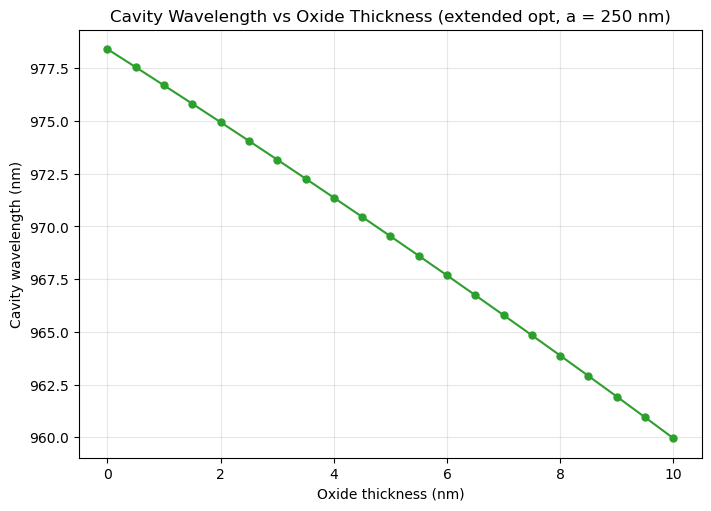

 t_ox (nm)           Q    f (norm)      λ (nm)
-----------------------------------------------------------------
      0.00  43715162.6     0.25552       978.4
      0.50  36548681.1     0.25574       977.5
      1.00  24737324.9     0.25597       976.7
      1.50  15771467.9     0.25620       975.8
      2.00  10211851.1     0.25643       974.9
      2.50   6850768.7     0.25666       974.1
      3.00   4762138.2     0.25689       973.2
      3.50   3412373.6     0.25713       972.3
      4.00   2506139.5     0.25737       971.4
      4.50   1876767.0     0.25761       970.5
      5.00   1426828.0     0.25786       969.5
      5.50   1097190.6     0.25810       968.6
      6.00    850669.1     0.25835       967.7
      6.50    663114.0     0.25860       966.7
      7.00    518385.5     0.25886       965.8
      7.50    405417.4     0.25911       964.8
      8.00    316448.2     0.25937       963.9
      8.50    245921.1     0.25963       962.9
      9.00    189783.5     0.25989       

In [26]:
# ── Plot full-oxidation sweep results ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax1.plot(t_ox_values, Qs_full, 'o-', lw=1.5, markersize=5)
ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Oxide Thickness (extended opt, consume_ratio = 0.5)')
ax1.grid(True, alpha=0.3)
plt.show()

# ── Wavelength conversion ──────────────────────────────────────────────────────
lambdas_full_nm = [a_nm / f for f in freqs_full]

fig, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax2.plot(t_ox_values, lambdas_full_nm, 'o-', lw=1.5, markersize=5, color='tab:green')
ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Cavity Wavelength vs Oxide Thickness (extended opt, a = {a_nm} nm)')
ax2.grid(True, alpha=0.3)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('=' * 65)
print(f'{"t_ox (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"\u03bb (nm)":>10}')
print('-' * 65)
for t, q, f, lam in zip(t_ox_values, Qs_full, freqs_full, lambdas_full_nm):
    print(f'{t:>10.2f}  {q:>10.1f}  {f:>10.5f}  {lam:>10.1f}')
print('=' * 65)

## Combined sweep: Q vs oxide thickness for different hole radii

In [27]:
# Combined sweep: oxide thickness for each hole radius
r_nm_list = [73, 74, 75, 76, 77]  # nm
t_ox_vals = np.linspace(0, 10, 21)  # nm
results = {}  # {r_nm: {'Qs': [...], 'freqs': [...]}}

options_sweep2 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for r_nm in r_nm_list:
    Qs, freqs = [], []
    f_prev = f_base  # re-seed for each radius

    print(f'\n--- r = {r_nm} nm ---')
    for t_ox_nm in t_ox_vals:
        phc_s = cavity_oxidized_ext(t_ox_nm, r_nm=r_nm)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep2)

        # Q-based mode selection: find candidates near f_prev, pick highest Q
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results[r_nm] = {'Qs': Qs, 'freqs': freqs}

print('\nCombined sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals, 'r_nm_list': np.array(r_nm_list)}
    for r_nm in r_nm_list:
        arrays[f'Qs_r{r_nm}'] = np.array(results[r_nm]['Qs'])
        arrays[f'freqs_r{r_nm}'] = np.array(results[r_nm]['freqs'])
    save_sweep('ext_radius_oxide', arrays, consume_ratio=0.5, r_nm_list=r_nm_list)


--- r = 73 nm ---
  t_ox =  0.00 nm,  Q =  2417738.9,  f = 0.25388  (mode 8)
  t_ox =  0.50 nm,  Q =  2751143.4,  f = 0.25410  (mode 8)
  t_ox =  1.00 nm,  Q =  3167280.6,  f = 0.25432  (mode 8)
  t_ox =  1.50 nm,  Q =  3695834.3,  f = 0.25454  (mode 8)
  t_ox =  2.00 nm,  Q =  4380606.8,  f = 0.25477  (mode 8)
  t_ox =  2.50 nm,  Q =  5287817.6,  f = 0.25499  (mode 8)
  t_ox =  3.00 nm,  Q =  6519889.6,  f = 0.25522  (mode 8)
  t_ox =  3.50 nm,  Q =  8237844.5,  f = 0.25545  (mode 8)
  t_ox =  4.00 nm,  Q = 10693924.9,  f = 0.25568  (mode 8)
  t_ox =  4.50 nm,  Q = 14259519.3,  f = 0.25592  (mode 8)
  t_ox =  5.00 nm,  Q = 19350094.8,  f = 0.25616  (mode 8)
  t_ox =  5.50 nm,  Q = 25871762.4,  f = 0.25640  (mode 8)
  t_ox =  6.00 nm,  Q = 31644618.2,  f = 0.25664  (mode 8)
  t_ox =  6.50 nm,  Q = 32093002.7,  f = 0.25688  (mode 8)
  t_ox =  7.00 nm,  Q = 26273597.4,  f = 0.25713  (mode 8)
  t_ox =  7.50 nm,  Q = 18809593.8,  f = 0.25737  (mode 8)
  t_ox =  8.00 nm,  Q = 12905323.4,  

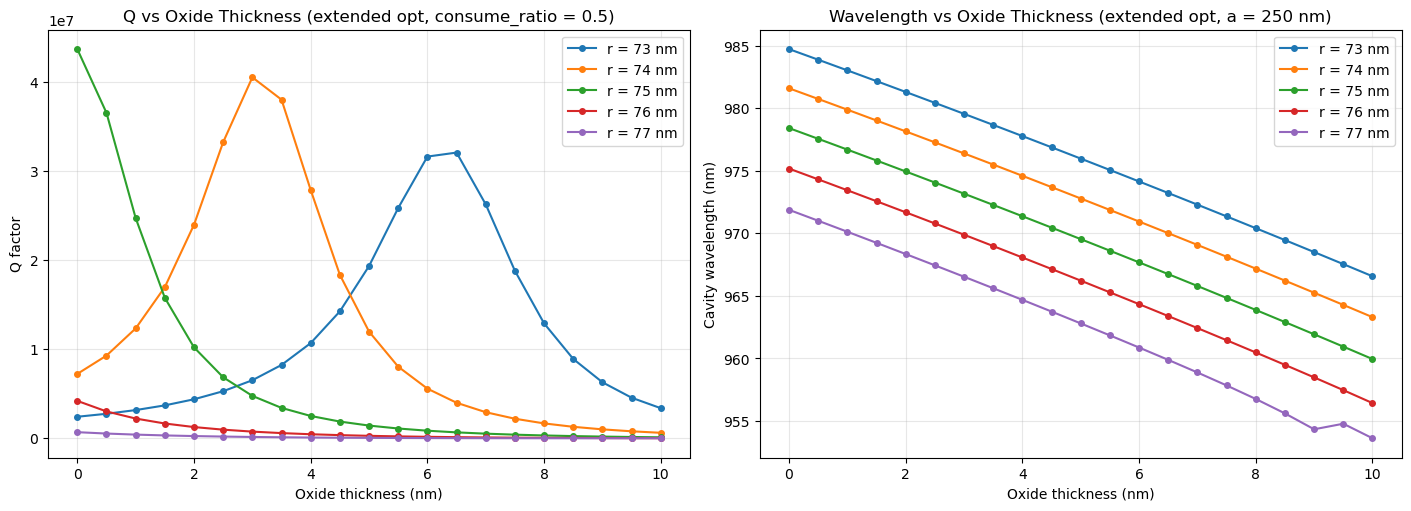

In [28]:
# ── Plot combined sweep results ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for r_nm in r_nm_list:
    ax1.plot(t_ox_vals, results[r_nm]['Qs'], 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')
    lambdas = [a_nm / f for f in results[r_nm]['freqs']]
    ax2.plot(t_ox_vals, lambdas, 'o-', ms=4, lw=1.5,
             label=f'r = {r_nm} nm')

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (extended opt, consume_ratio = 0.5)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (extended opt, a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Sweep: Q vs oxide thickness for different consume ratios

In [29]:
# Combined sweep: oxide thickness for each consume_ratio (standard r = 75 nm)
cr_list = np.linspace(0, 1.0, 6)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
t_ox_vals_cr = np.linspace(0, 10, 21)  # nm
results_cr = {}  # {cr: {'Qs': [...], 'freqs': [...]}}

options_sweep3 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for cr in cr_list:
    Qs, freqs = [], []
    f_prev = f_base

    print(f'\n--- consume_ratio = {cr:.2f} ---')
    for t_ox_nm in t_ox_vals_cr:
        phc_s = cavity_oxidized_ext(t_ox_nm, consume_ratio=cr)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep3)

        # Q-based mode selection: find candidates near f_prev, pick highest Q
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where(np.abs(all_freqs - f_prev) < 0.005)[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  t_ox = {t_ox_nm:5.2f} nm,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_cr[cr] = {'Qs': Qs, 'freqs': freqs}

print('\nConsume ratio sweep complete.')

if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_vals_cr, 'cr_list': np.array(cr_list)}
    for cr in cr_list:
        arrays[f'Qs_cr{cr:.2f}'] = np.array(results_cr[cr]['Qs'])
        arrays[f'freqs_cr{cr:.2f}'] = np.array(results_cr[cr]['freqs'])
    save_sweep('ext_consume_ratio_oxide', arrays, r_nm=75, cr_list=cr_list.tolist())


--- consume_ratio = 0.00 ---
  t_ox =  0.00 nm,  Q = 43715162.6,  f = 0.25552  (mode 8)
  t_ox =  0.50 nm,  Q = 41530172.5,  f = 0.25539  (mode 8)
  t_ox =  1.00 nm,  Q = 35685297.3,  f = 0.25526  (mode 8)
  t_ox =  1.50 nm,  Q = 28975267.0,  f = 0.25513  (mode 8)
  t_ox =  2.00 nm,  Q = 23058739.8,  f = 0.25500  (mode 8)
  t_ox =  2.50 nm,  Q = 18374754.2,  f = 0.25487  (mode 8)
  t_ox =  3.00 nm,  Q = 14809724.7,  f = 0.25475  (mode 8)
  t_ox =  3.50 nm,  Q = 12117289.5,  f = 0.25463  (mode 8)
  t_ox =  4.00 nm,  Q = 10070477.1,  f = 0.25451  (mode 8)
  t_ox =  4.50 nm,  Q =  8494742.7,  f = 0.25439  (mode 8)
  t_ox =  5.00 nm,  Q =  7263719.9,  f = 0.25427  (mode 8)
  t_ox =  5.50 nm,  Q =  6287551.4,  f = 0.25415  (mode 8)
  t_ox =  6.00 nm,  Q =  5502335.0,  f = 0.25403  (mode 8)
  t_ox =  6.50 nm,  Q =  4862247.6,  f = 0.25392  (mode 8)
  t_ox =  7.00 nm,  Q =  4334035.8,  f = 0.25381  (mode 8)
  t_ox =  7.50 nm,  Q =  3893242.2,  f = 0.25370  (mode 8)
  t_ox =  8.00 nm,  Q =  3

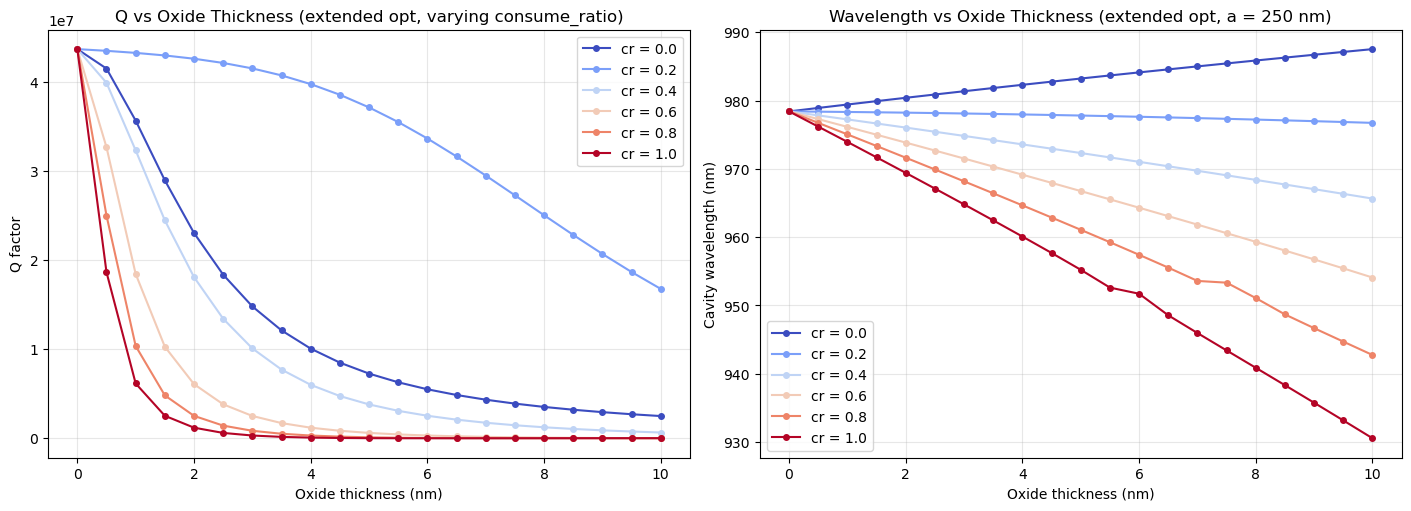

In [30]:
# ── Plot consume_ratio sweep results ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.coolwarm
colors = [cmap(i / (len(cr_list) - 1)) for i in range(len(cr_list))]

for i, cr in enumerate(cr_list):
    label = f'cr = {cr:.1f}'
    ax1.plot(t_ox_vals_cr, results_cr[cr]['Qs'], 'o-', ms=4, lw=1.5, label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_cr[cr]['freqs']]
    ax2.plot(t_ox_vals_cr, lambdas, 'o-', ms=4, lw=1.5, label=label, color=colors[i])

ax1.set_xlabel('Oxide thickness (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Oxide Thickness (extended opt, varying consume_ratio)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Oxide thickness (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Oxide Thickness (extended opt, a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Lattice constant sweep (no oxide, constant r/a and d/a)

In [31]:
# Sweep lattice constant (no oxide, r/a and d/a constant)
# Since r/a and d/a are fixed, the normalized simulation is invariant.
# Only the physical wavelength lambda = a / f_norm changes.
a_nm_list = np.linspace(220, 280, 13)  # nm
Qs_a = []
freqs_a = []
lambdas_a = []

options_a = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
             'gradients': 'approx', 'compute_im': False}

print(f'Lattice constant sweep (r/a = {ra:.4f}, d/a = {dslab:.4f}, no oxide):')
print(f'{"a (nm)":>8}  {"r (nm)":>8}  {"d (nm)":>8}  {"f (norm)":>10}  {"\u03bb (nm)":>10}  {"Q":>12}')
print('-' * 70)

for a_val in a_nm_list:
    # Build unoxidized cavity \u2014 normalized structure is identical for all a_nm
    phc_a = cavity_oxidized_ext(0)
    gme_a = legume.GuidedModeExp(phc_a, gmax=gmax, truncate_g=truncate_g)
    gme_a.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_a)

    # Q-based mode selection
    all_freqs = gme_a.freqs[0, :]
    candidates = np.where(np.abs(all_freqs - f_base) < 0.005)[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_a.compute_rad(0, [c])
        Qc = gme_a.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    f_norm = gme_a.freqs[0, mind]
    lam = a_val / f_norm

    Qs_a.append(best_Q)
    freqs_a.append(f_norm)
    lambdas_a.append(lam)
    print(f'{a_val:8.1f}  {ra*a_val:8.1f}  {dslab*a_val:8.1f}  {f_norm:10.5f}  {lam:10.1f}  {best_Q:12.1f}')

print('\nLattice constant sweep complete.')
print(f'Note: Q is constant ({Qs_a[0]:.0f}) because normalized geometry is invariant.')

if SAVE_DATA:
    save_sweep('ext_lattice_constant', {
        'a_nm': np.array(a_nm_list),
        'Qs': np.array(Qs_a),
        'freqs': np.array(freqs_a),
        'lambdas_nm': np.array(lambdas_a),
    }, ra=ra, dslab=dslab, t_ox_nm=0, consume_ratio=0)

Lattice constant sweep (r/a = 0.3000, d/a = 0.6800, no oxide):
  a (nm)    r (nm)    d (nm)    f (norm)      λ (nm)             Q
----------------------------------------------------------------------
   220.0      66.0     149.6     0.25552       861.0    43715162.6
   225.0      67.5     153.0     0.25552       880.6    43715162.6
   230.0      69.0     156.4     0.25552       900.1    43715162.6
   235.0      70.5     159.8     0.25552       919.7    43715162.6
   240.0      72.0     163.2     0.25552       939.3    43715162.6
   245.0      73.5     166.6     0.25552       958.8    43715162.6
   250.0      75.0     170.0     0.25552       978.4    43715162.6
   255.0      76.5     173.4     0.25552       998.0    43715162.6
   260.0      78.0     176.8     0.25552      1017.5    43715162.6
   265.0      79.5     180.2     0.25552      1037.1    43715162.6
   270.0      81.0     183.6     0.25552      1056.7    43715162.6
   275.0      82.5     187.0     0.25552      1076.2    437151

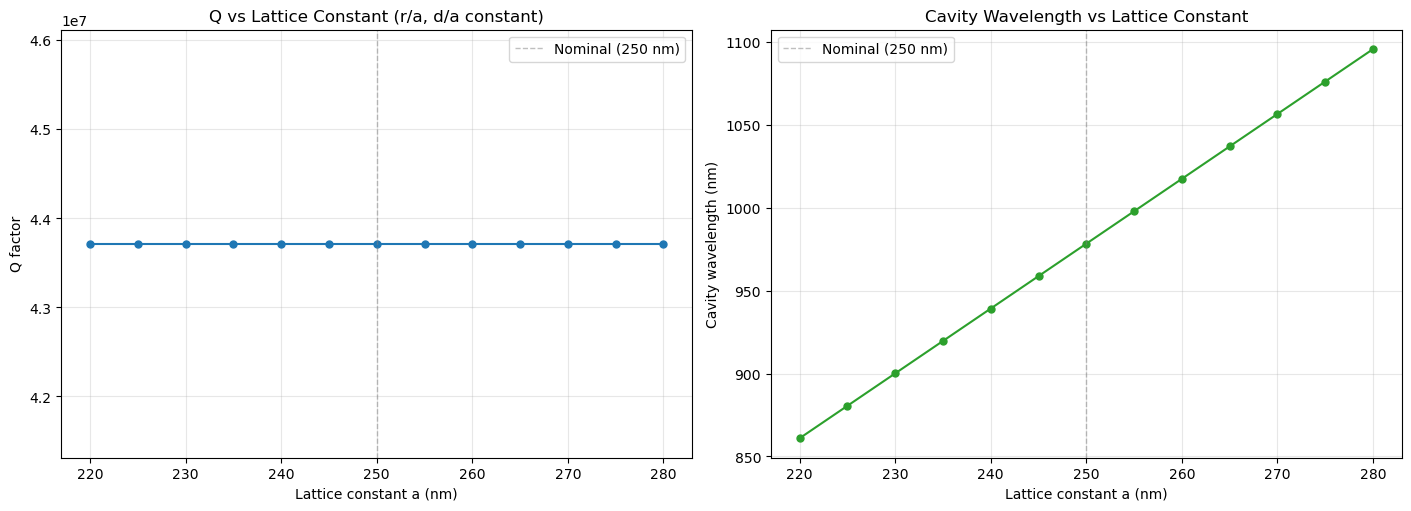

In [32]:
# ── Plot lattice constant sweep results ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax1.plot(a_nm_list, Qs_a, 'o-', lw=1.5, ms=5)
ax1.axvline(250, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (250 nm)')
ax1.set_xlabel('Lattice constant a (nm)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Lattice Constant (r/a, d/a constant)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(a_nm_list, lambdas_a, 'o-', lw=1.5, ms=5, color='tab:green')
ax2.axvline(250, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal (250 nm)')
ax2.set_xlabel('Lattice constant a (nm)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title('Cavity Wavelength vs Lattice Constant')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Hole Shape Analysis (no oxide)

Study the effect of non-ideal hole shapes on Q factor:
1. **Conical taper** — sidewall angle from RIE etching
2. **Piecewise taper** — independent top/bottom sidewall angles (barrel, hourglass)
3. **Elliptical holes** — varying ellipticity and rotation angle

In [9]:
from legume import Ellipse

n_slices_shape = 24  # staircase sub-layers for taper studies

# ── Conical taper ──────────────────────────────────────────────────────────
def cavity_conical_ext(taper_angle_deg, n_slices=24, r_nm=None):
    """L3 cavity with conical (tapered) holes.
    r_top = ra, r_bottom = ra - dslab * tan(angle)."""
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    taper_rad = np.radians(taper_angle_deg)
    r_top = r_a
    r_bottom = r_a - dslab * np.tan(taper_rad)
    if r_bottom <= 0:
        raise ValueError(f'Taper too large: r_bottom = {r_bottom*a_nm:.1f} nm')

    d_slice = dslab / n_slices
    phc = legume.PhotCryst(lattice)

    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice
        frac = z_center / dslab
        r_k = r_top * (1 - frac) + r_bottom * frac
        phc.add_layer(d=d_slice, eps_b=n_slab**2)

        for ic in range(nc):
            yc = yp[ic] + dy[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0
            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))
            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_k), layer=k)
    return phc


# ── Piecewise taper (barrel / hourglass) ──────────────────────────────────
def cavity_piecewise_ext(angle_top_deg, angle_bottom_deg, n_slices=24, r_nm=None):
    """L3 cavity with piecewise-linear tapered holes.
    Top half: r(z) = ra - z*tan(angle_top)
    Bottom half: r(z) = ra - (dslab-z)*tan(angle_bottom)"""
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    tan_top = np.tan(np.radians(angle_top_deg))
    tan_bot = np.tan(np.radians(angle_bottom_deg))
    d_slice = dslab / n_slices

    r_slices = []
    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice
        if z_center <= dslab / 2:
            r_k = r_a - z_center * tan_top
        else:
            r_k = r_a - (dslab - z_center) * tan_bot
        r_slices.append(r_k)
    if min(r_slices) <= 0:
        raise ValueError(f'Radius goes to zero: min r = {min(r_slices)*a_nm:.1f} nm')

    phc = legume.PhotCryst(lattice)
    for k in range(n_slices):
        phc.add_layer(d=d_slice, eps_b=n_slab**2)
        for ic in range(nc):
            yc = yp[ic] + dy[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0
            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))
            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_slices[k]), layer=k)
    return phc


# ── Elliptical holes ──────────────────────────────────────────────────────
def cavity_elliptical_ext(ellipticity, phi_deg=0, r_nm=None):
    """L3 cavity with elliptical holes (constant area).
    e = ry/rx.  rx = r/sqrt(e), ry = r*sqrt(e).  phi = rotation in degrees."""
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    rx = r_a / np.sqrt(ellipticity)
    ry = r_a * np.sqrt(ellipticity)
    phi = np.radians(phi_deg)

    phc = legume.PhotCryst(lattice)
    phc.add_layer(d=dslab, eps_b=n_slab**2)
    for ic in range(nc):
        yc = yp[ic] + dy[ic]
        xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0
        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))
        for (px, py) in positions:
            phc.add_shape(Ellipse(x_cent=px, y_cent=py, rx=rx, ry=ry, phi=phi),
                          layer=0)
    return phc

print('Cavity builders defined: cavity_conical_ext, cavity_piecewise_ext, cavity_elliptical_ext')

Cavity builders defined: cavity_conical_ext, cavity_piecewise_ext, cavity_elliptical_ext


### Conical taper sweep

In [10]:
# Sweep taper angle 0-5 degrees
taper_angles = np.linspace(0, 5, 21)
Qs_taper = []
freqs_taper = []

options_taper = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base

print('Sweeping taper angle:')
for angle in taper_angles:
    phc_s = cavity_conical_ext(angle, n_slices=n_slices_shape)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_taper)

    all_freqs = gme_s.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_s.compute_rad(0, [c])
        Qc = gme_s.freqs[0, c] / (2 * fim[0])
        if Qc > 0 and Qc > best_Q:
            best_Q, mind = Qc, c

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s
    Qs_taper.append(best_Q)
    freqs_taper.append(f_s)

    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  angle = {angle:5.2f} deg,  r_bot = {r_bot*a_nm:5.1f} nm,  '
          f'Q = {best_Q:10.1f},  f = {f_s:.5f}')

Qs_taper = np.array(Qs_taper)
freqs_taper = np.array(freqs_taper)
print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('ext_taper_angle', {
        'taper_angles': taper_angles,
        'Qs': Qs_taper,
        'freqs': freqs_taper,
    }, n_slices=n_slices_shape)

Sweeping taper angle:
  angle =  0.00 deg,  r_bot =  75.0 nm,  Q = 43715162.6,  f = 0.25552
  angle =  0.25 deg,  r_bot =  74.3 nm,  Q = 22892684.6,  f = 0.25521
  angle =  0.50 deg,  r_bot =  73.5 nm,  Q =  9984955.6,  f = 0.25491
  angle =  0.75 deg,  r_bot =  72.8 nm,  Q =  5417698.4,  f = 0.25462
  angle =  1.00 deg,  r_bot =  72.0 nm,  Q =  3406393.7,  f = 0.25434
  angle =  1.25 deg,  r_bot =  71.3 nm,  Q =  2342876.3,  f = 0.25406
  angle =  1.50 deg,  r_bot =  70.5 nm,  Q =  1705165.7,  f = 0.25379
  angle =  1.75 deg,  r_bot =  69.8 nm,  Q =  1288000.5,  f = 0.25353
  angle =  2.00 deg,  r_bot =  69.1 nm,  Q =   997926.4,  f = 0.25327
  angle =  2.25 deg,  r_bot =  68.3 nm,  Q =   787356.0,  f = 0.25301
  angle =  2.50 deg,  r_bot =  67.6 nm,  Q =   629785.9,  f = 0.25276
  angle =  2.75 deg,  r_bot =  66.8 nm,  Q =   509308.8,  f = 0.25252
  angle =  3.00 deg,  r_bot =  66.1 nm,  Q =   415754.7,  f = 0.25228
  angle =  3.25 deg,  r_bot =  65.3 nm,  Q =   342273.4,  f = 0.2520

Loading from: data/2026-04-01_135028_ext_taper_angle


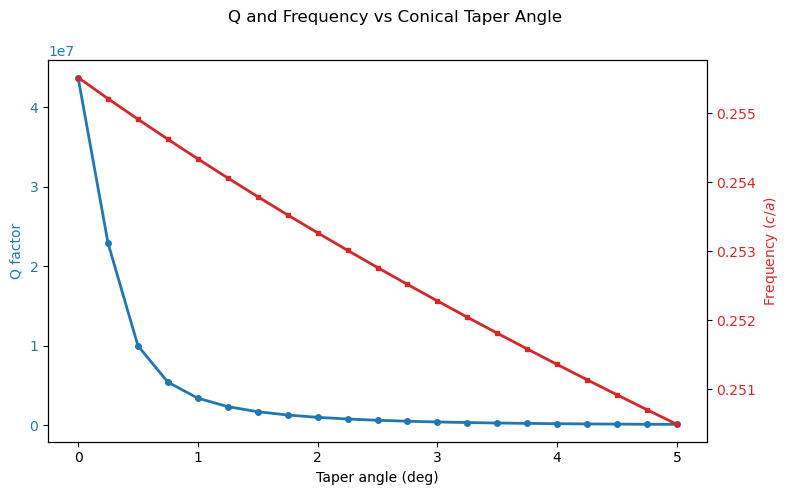

In [11]:
# ── Taper sweep plot ────────────────────────────────────────────────────
import glob, os

folders = sorted(glob.glob('data/*_ext_taper_angle'))
if not folders:
    raise FileNotFoundError('No ext_taper_angle data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

taper_angles = np.load(os.path.join(folder, 'taper_angles.npy'))
Qs_taper     = np.load(os.path.join(folder, 'Qs.npy'))
freqs_taper  = np.load(os.path.join(folder, 'freqs.npy'))

fig, ax1 = plt.subplots(figsize=(8, 5))
color_q, color_f = '#1f77b4', '#d62728'

ax1.plot(taper_angles, Qs_taper, 'o-', color=color_q, lw=2, ms=4)
ax1.set_xlabel('Taper angle (deg)')
ax1.set_ylabel('Q factor', color=color_q)
ax1.tick_params(axis='y', labelcolor=color_q)

ax2 = ax1.twinx()
ax2.plot(taper_angles, freqs_taper, 's-', color=color_f, lw=2, ms=3)
ax2.set_ylabel('Frequency ($c/a$)', color=color_f)
ax2.tick_params(axis='y', labelcolor=color_f)

fig.suptitle('Q and Frequency vs Conical Taper Angle')
fig.tight_layout()
plt.show()

### Piecewise taper heatmap (barrel / hourglass)

Vary top and bottom sidewall angles independently.  
Positive angle = narrows towards slab centre. Negative = widens (barrel).

In [12]:
# 2D heatmap sweep: angle_top vs angle_bottom
angles_pw = np.linspace(-3, 5, 9)  # 1 deg steps, 45 runs
n_angles = len(angles_pw)

Q_matrix = np.full((n_angles, n_angles), np.nan)
f_matrix = np.full((n_angles, n_angles), np.nan)

options_pw = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
               'gradients': 'approx', 'compute_im': False}

total = n_angles * (n_angles + 1) // 2
count = 0

print(f'Piecewise-taper heatmap: {total} runs ({n_angles}x{n_angles}, lower triangle)')
for i, a_top in enumerate(angles_pw):
    f_prev = f_base
    for j, a_bot in enumerate(angles_pw):
        if j > i:
            continue
        count += 1
        try:
            phc_s = cavity_piecewise_ext(a_top, a_bot, n_slices=n_slices_shape)
        except ValueError as e:
            print(f'  [{count:3d}/{total}] top={a_top:+5.1f}, bot={a_bot:+5.1f} deg  SKIPPED ({e})')
            continue

        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_pw)

        all_freqs = gme_s.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > 0 and Qc > best_Q:
                best_Q, mind = Qc, c

        if best_Q > 0:
            f_s = gme_s.freqs[0, mind]
            f_prev = f_s
            Q_matrix[i, j] = best_Q
            f_matrix[i, j] = f_s
            if i != j:
                Q_matrix[j, i] = best_Q
                f_matrix[j, i] = f_s

        print(f'  [{count:3d}/{total}] top={a_top:+5.1f}, bot={a_bot:+5.1f} deg  '
              f'Q={best_Q:10.1f}  f={gme_s.freqs[0, mind]:.5f}')

print('\nHeatmap sweep complete.')

if SAVE_DATA:
    save_sweep('ext_piecewise_taper_heatmap', {
        'angles': angles_pw,
        'Q_matrix': Q_matrix,
        'f_matrix': f_matrix,
    }, n_slices=n_slices_shape)

Piecewise-taper heatmap: 45 runs (9x9, lower triangle)
  [  1/45] top= -3.0, bot= -3.0 deg  Q=  377568.3  f=0.25753
  [  2/45] top= -2.0, bot= -3.0 deg  Q=  709647.9  f=0.25719
  [  3/45] top= -2.0, bot= -2.0 deg  Q= 1446150.6  f=0.25683
  [  4/45] top= -1.0, bot= -3.0 deg  Q= 1260007.0  f=0.25690
  [  5/45] top= -1.0, bot= -2.0 deg  Q= 2914155.8  f=0.25651
  [  6/45] top= -1.0, bot= -1.0 deg  Q= 7388903.6  f=0.25616
  [  7/45] top= +0.0, bot= -3.0 deg  Q= 2040953.9  f=0.25664
  [  8/45] top= +0.0, bot= -2.0 deg  Q= 5380085.3  f=0.25622
  [  9/45] top= +0.0, bot= -1.0 deg  Q=17631958.9  f=0.25585
  [ 10/45] top= +0.0, bot= +0.0 deg  Q=43715162.6  f=0.25552
  [ 11/45] top= +1.0, bot= -3.0 deg  Q= 2813800.9  f=0.25641
  [ 12/45] top= +1.0, bot= -2.0 deg  Q= 7396836.9  f=0.25597
  [ 13/45] top= +1.0, bot= -1.0 deg  Q=19241884.4  f=0.25558
  [ 14/45] top= +1.0, bot= +0.0 deg  Q=22455750.5  f=0.25522
  [ 15/45] top= +1.0, bot= +1.0 deg  Q=12273399.1  f=0.25490
  [ 16/45] top= +2.0, bot= -3.

Loading from: data/2026-04-01_142012_ext_piecewise_taper_heatmap


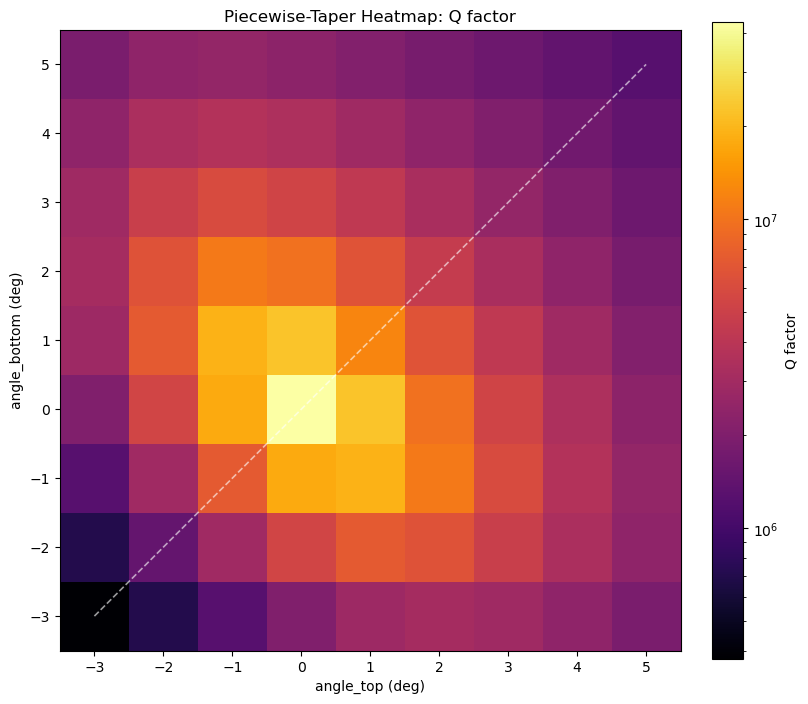

In [13]:
# ── Piecewise-taper heatmap plot ──────────────────────────────────────────
import glob, os
from matplotlib.colors import LogNorm

folders = sorted(glob.glob('data/*_ext_piecewise_taper_heatmap'))
if not folders:
    raise FileNotFoundError('No ext_piecewise_taper_heatmap data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

angles_pw = np.load(os.path.join(folder, 'angles.npy'))
Q_matrix  = np.load(os.path.join(folder, 'Q_matrix.npy'))

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

da = angles_pw[1] - angles_pw[0]
edges = np.append(angles_pw - da/2, angles_pw[-1] + da/2)

Q_valid = Q_matrix[Q_matrix > 0]
use_log = (Q_valid.max() / Q_valid.min() > 100) if len(Q_valid) > 0 else False
norm = LogNorm(vmin=Q_valid.min(), vmax=Q_valid.max()) if use_log else None

pcm = ax.pcolormesh(edges, edges, Q_matrix, cmap='inferno', shading='flat', norm=norm)
fig.colorbar(pcm, ax=ax, label='Q factor')

ax.plot([angles_pw[0], angles_pw[-1]], [angles_pw[0], angles_pw[-1]],
        'w--', lw=1.2, alpha=0.6)

ax.set_xlabel('angle_top (deg)')
ax.set_ylabel('angle_bottom (deg)')
ax.set_title('Piecewise-Taper Heatmap: Q factor')
ax.set_aspect('equal')
plt.show()

### Elliptical holes

Replace circular holes with ellipses of the same area ($r_x r_y = r^2$).  
Ellipticity $e = r_y/r_x$: $e=1$ circular, $e>1$ elongated along $y$ ($\Gamma$-M), $e<1$ along $x$ (cavity axis).  
Rotation angle $\phi$: rotates each ellipse CCW. Equivalence: $(e,\,\phi) \equiv (1/e,\,\phi+90°)$.

In [18]:
# Sweep ellipticity (constant hole area) — outward from e=1.0
ellipticities = np.linspace(0.6, 1.6, 21)
i_base = np.argmin(np.abs(ellipticities - 1.0))  # start here

Qs_ellip = np.full(len(ellipticities), np.nan)
freqs_ellip = np.full(len(ellipticities), np.nan)

options_ellip = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

def _run_ellip(idx, f_prev_val):
    e = ellipticities[idx]
    phc_e = cavity_elliptical_ext(e)
    gme_e = legume.GuidedModeExp(phc_e, gmax=gmax, truncate_g=truncate_g)
    gme_e.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_ellip)

    all_freqs = gme_e.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    if len(candidates) == 0:
        print(f'  e = {e:5.2f}  NO MODE IN BANDGAP')
        return f_prev_val

    freq_dists = np.abs(all_freqs[candidates] - f_prev_val)
    mind = candidates[np.argmin(freq_dists)]
    (fim, _, _) = gme_e.compute_rad(0, [mind])
    best_Q = gme_e.freqs[0, mind] / (2 * fim[0])
    f_e = gme_e.freqs[0, mind]

    Qs_ellip[idx] = best_Q
    freqs_ellip[idx] = f_e

    rxe = ra / np.sqrt(e)
    rye = ra * np.sqrt(e)
    print(f'  e = {e:5.2f}  rx = {rxe*a_nm:5.1f} nm  ry = {rye*a_nm:5.1f} nm  '
          f'Q = {best_Q:10.1f}  f = {f_e:.5f}')
    return f_e

# Forward sweep: e=1.0 → 1.6
print('Sweeping ellipticity (outward from e=1.0):')
print('--- Forward (e=1.0 -> 1.6) ---')
f_prev = f_base
for idx in range(i_base, len(ellipticities)):
    f_prev = _run_ellip(idx, f_prev)

# Backward sweep: e<1.0 → 0.6
print('--- Backward (e=1.0 -> 0.6) ---')
f_prev = f_base
for idx in range(i_base - 1, -1, -1):
    f_prev = _run_ellip(idx, f_prev)

print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('ext_ellipticity', {
        'ellipticities': ellipticities,
        'Qs': Qs_ellip,
        'freqs': freqs_ellip,
    }, r_nm=ra*a_nm)

Sweeping ellipticity (outward from e=1.0):
--- Forward (e=1.0 -> 1.6) ---
  e =  1.00  rx =  75.0 nm  ry =  75.0 nm  Q = 43715162.6  f = 0.25552
  e =  1.05  rx =  73.2 nm  ry =  76.9 nm  Q = 16005160.1  f = 0.25565
  e =  1.10  rx =  71.5 nm  ry =  78.7 nm  Q =  5655389.0  f = 0.25583
  e =  1.15  rx =  69.9 nm  ry =  80.4 nm  Q =  2712875.4  f = 0.25604
  e =  1.20  rx =  68.5 nm  ry =  82.2 nm  Q =  1538862.5  f = 0.25629
  e =  1.25  rx =  67.1 nm  ry =  83.9 nm  Q =   963296.0  f = 0.25656
  e =  1.30  rx =  65.8 nm  ry =  85.5 nm  Q =   642989.1  f = 0.25684
  e =  1.35  rx =  64.5 nm  ry =  87.1 nm  Q =   449081.7  f = 0.25715
  e =  1.40  rx =  63.4 nm  ry =  88.7 nm  Q =   324463.9  f = 0.25747
  e =  1.45  rx =  62.3 nm  ry =  90.3 nm  Q =   240711.0  f = 0.25779
  e =  1.50  rx =  61.2 nm  ry =  91.9 nm  Q =   182424.6  f = 0.25813
  e =  1.55  rx =  60.2 nm  ry =  93.4 nm  Q =   140709.2  f = 0.25847
  e =  1.60  rx =  59.3 nm  ry =  94.9 nm  Q =   110159.6  f = 0.25882
---

Loading from: data/2026-04-01_153033_ext_ellipticity


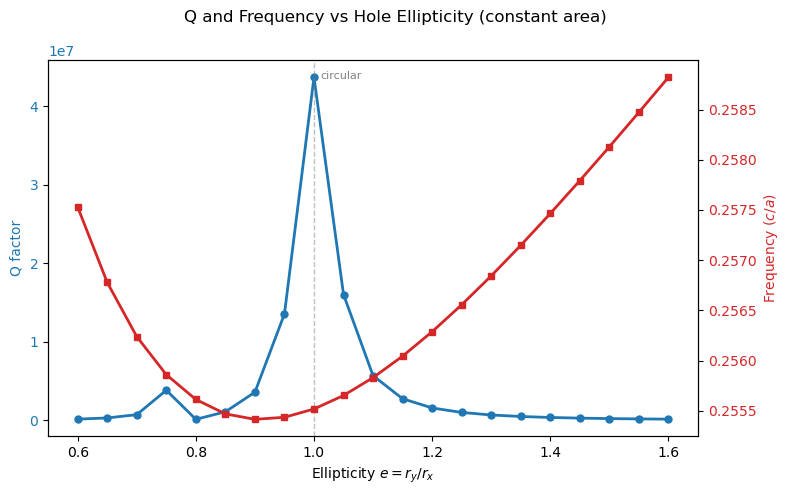

In [19]:
# ── Ellipticity sweep plot ────────────────────────────────────────────────
import glob, os

folders = sorted(glob.glob('data/*_ext_ellipticity'))
if not folders:
    raise FileNotFoundError('No ext_ellipticity data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

ellipticities = np.load(os.path.join(folder, 'ellipticities.npy'))
Qs_ellip      = np.load(os.path.join(folder, 'Qs.npy'))
freqs_ellip   = np.load(os.path.join(folder, 'freqs.npy'))

fig, ax1 = plt.subplots(figsize=(8, 5))
color_q, color_f = '#1f77b4', '#d62728'

ax1.plot(ellipticities, Qs_ellip, 'o-', color=color_q, lw=2, ms=5)
ax1.set_xlabel('Ellipticity $e = r_y / r_x$')
ax1.set_ylabel('Q factor', color=color_q)
ax1.tick_params(axis='y', labelcolor=color_q)
ax1.axvline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
ax1.text(1.01, ax1.get_ylim()[1]*0.97, 'circular', fontsize=8, color='gray', va='top')

ax2 = ax1.twinx()
ax2.plot(ellipticities, freqs_ellip, 's-', color=color_f, lw=2, ms=4)
ax2.set_ylabel('Frequency ($c/a$)', color=color_f)
ax2.tick_params(axis='y', labelcolor=color_f)

fig.suptitle('Q and Frequency vs Hole Ellipticity (constant area)')
fig.tight_layout()
plt.show()

### Ellipticity × rotation angle

In [20]:
# 2D sweep: ellipticity vs rotation angle — ellipticity swept outward from 1.0
ellipticities_2d = np.linspace(0.7, 1.4, 8)
phi_degs = np.linspace(0, 90, 10)
n_e = len(ellipticities_2d)
n_phi = len(phi_degs)
i_base_2d = np.argmin(np.abs(ellipticities_2d - 1.0))

Q_map = np.full((n_e, n_phi), np.nan)
f_map = np.full((n_e, n_phi), np.nan)

options_er = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
               'gradients': 'approx', 'compute_im': False}

def _run_er(i_e, f_seed):
    e = ellipticities_2d[i_e]
    f_prev = f_seed
    for i_phi, phi in enumerate(phi_degs):
        phc_er = cavity_elliptical_ext(e, phi_deg=phi)
        gme_er = legume.GuidedModeExp(phc_er, gmax=gmax, truncate_g=truncate_g)
        gme_er.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_er)

        all_freqs = gme_er.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        if len(candidates) == 0:
            print(f'  e={e:5.2f}  phi={phi:5.1f} deg  NO MODE')
            continue

        freq_dists = np.abs(all_freqs[candidates] - f_prev)
        mind = candidates[np.argmin(freq_dists)]
        (fim, _, _) = gme_er.compute_rad(0, [mind])
        best_Q = gme_er.freqs[0, mind] / (2 * fim[0])

        if best_Q > 0:
            f_er = gme_er.freqs[0, mind]
            f_prev = f_er
            Q_map[i_e, i_phi] = best_Q
            f_map[i_e, i_phi] = f_er

        print(f'  e={e:5.2f}  phi={phi:5.1f} deg  '
              f'Q={best_Q:10.1f}  f={gme_er.freqs[0, mind]:.5f}')
    # Return phi=0 frequency as seed for next ellipticity step
    return f_map[i_e, 0] if not np.isnan(f_map[i_e, 0]) else f_seed

total = n_e * n_phi
print(f'Ellipticity x rotation sweep: {total} runs ({n_e} x {n_phi}), outward from e=1.0')

# Forward: e near 1.0 -> 1.4
print('--- Forward ---')
f_seed = f_base
for i_e in range(i_base_2d, n_e):
    f_seed = _run_er(i_e, f_seed)

# Backward: e near 1.0 -> 0.7
print('--- Backward ---')
f_seed = f_base
for i_e in range(i_base_2d - 1, -1, -1):
    f_seed = _run_er(i_e, f_seed)

print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('ext_ellipticity_rotation', {
        'ellipticities': ellipticities_2d,
        'phi_degs': phi_degs,
        'Q_map': Q_map,
        'f_map': f_map,
    }, r_nm=ra*a_nm)

Ellipticity x rotation sweep: 80 runs (8 x 10), outward from e=1.0
--- Forward ---
  e= 1.00  phi=  0.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 10.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 20.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 30.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 40.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 50.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 60.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 70.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 80.0 deg  Q=43715162.6  f=0.25552
  e= 1.00  phi= 90.0 deg  Q=43715162.6  f=0.25552
  e= 1.10  phi=  0.0 deg  Q= 5655389.0  f=0.25583
  e= 1.10  phi= 10.0 deg  Q= 2249047.6  f=0.25581
  e= 1.10  phi= 20.0 deg  Q=  921440.6  f=0.25574
  e= 1.10  phi= 30.0 deg  Q=  578249.5  f=0.25566
  e= 1.10  phi= 40.0 deg  Q=  488520.4  f=0.25557
  e= 1.10  phi= 50.0 deg  Q=  521029.8  f=0.25550
  e= 1.10  phi= 60.0 deg  Q=  690215.9  f=0.25545
  e= 1.10  phi= 70.0 deg  Q= 1158710.6  f=0.25543
  e= 1.10  phi= 8

Loading from: data/2026-04-01_154537_ext_ellipticity_rotation


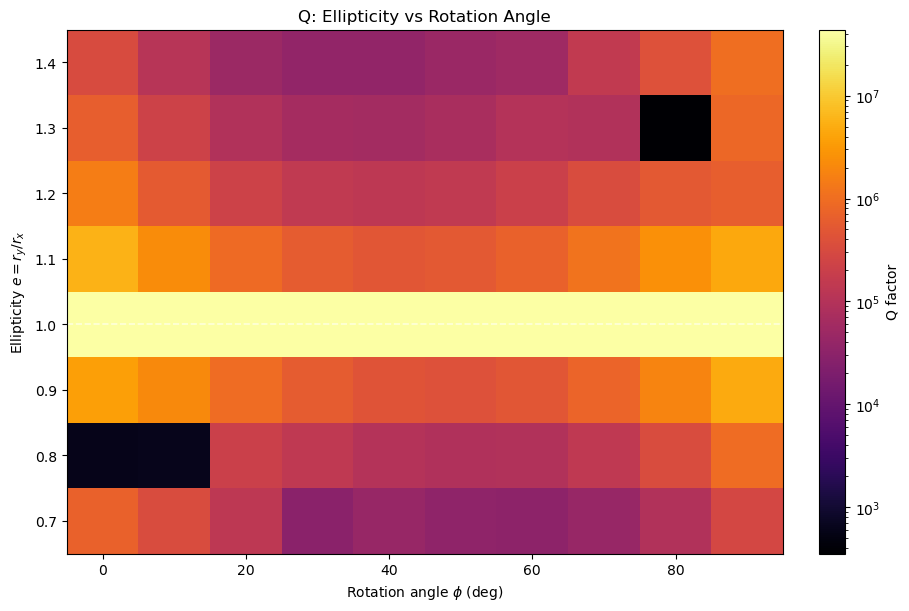

In [21]:
# ── Ellipticity x rotation heatmap plot ─────────────────────────────────
import glob, os
from matplotlib.colors import LogNorm

folders = sorted(glob.glob('data/*_ext_ellipticity_rotation'))
if not folders:
    raise FileNotFoundError('No ext_ellipticity_rotation data found.')
folder = folders[-1]
print(f'Loading from: {folder}')

ellipticities_2d = np.load(os.path.join(folder, 'ellipticities.npy'))
phi_degs         = np.load(os.path.join(folder, 'phi_degs.npy'))
Q_map            = np.load(os.path.join(folder, 'Q_map.npy'))

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)

de = ellipticities_2d[1] - ellipticities_2d[0]
dp = phi_degs[1] - phi_degs[0]
e_edges = np.append(ellipticities_2d - de/2, ellipticities_2d[-1] + de/2)
p_edges = np.append(phi_degs - dp/2, phi_degs[-1] + dp/2)

Q_valid = Q_map[Q_map > 0]
use_log = (Q_valid.max() / Q_valid.min() > 100) if len(Q_valid) > 0 else False
norm = LogNorm(vmin=Q_valid.min(), vmax=Q_valid.max()) if use_log else None

pcm = ax.pcolormesh(p_edges, e_edges, Q_map, cmap='inferno', shading='flat', norm=norm)
fig.colorbar(pcm, ax=ax, label='Q factor')

ax.axhline(1.0, color='white', ls='--', lw=1.2, alpha=0.6)

ax.set_xlabel('Rotation angle $\\phi$ (deg)')
ax.set_ylabel('Ellipticity $e = r_y / r_x$')
ax.set_title('Q: Ellipticity vs Rotation Angle')
plt.show()